# `out_dim=65536` 일 때 ViT-S 파라미터 규모 해부

**질문**: `out_dim=65536` 일 때 ViT-S의 파라미터 규모는 어떻게 되는가?

**답**: DINOHead가 약 **22.4M** 으로 backbone(**21.7M**)보다 커진다.
마지막 층 하나가 $256 \times 65536 = 16.8$M 을 차지하기 때문이다.

이 노트북은 그 숫자를 **손계산 → 실제 `nn.Module` 대조 → $K$ 스윕 → 메모리 환산**
순서로 직접 확인한다.

In [1]:
# 필요 패키지: torch>=2.0, plotly>=5, kaleido  (CPU만으로 충분)
import os
import sys

import torch
import torch.nn as nn

sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
import vision_transformer as vits
from vision_transformer import DINOHead

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
torch.manual_seed(0)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. DINOHead의 구조 — 파라미터가 어디에 쌓이는가

`DINOHead(in_dim, out_dim, nlayers=3, hidden_dim=2048, bottleneck_dim=256)` 의 실제 구성은

$$
\underbrace{D \to 2048 \to 2048 \to 256}_{\text{3-layer MLP (bias 있음)}}
\;\longrightarrow\; \ell_2\text{-normalize}
\;\longrightarrow\; \underbrace{256 \to K}_{\texttt{last\_layer}\ (\text{bias 없음})}
$$

선형층 하나의 파라미터 수는 $\text{in} \times \text{out} + \text{out}$ (bias 포함),
bias가 없으면 $\text{in} \times \text{out}$ 이다.

`last_layer` 는 `nn.utils.weight_norm` 으로 감싸져 있어 $W$ 가 두 텐서로 재매개화된다:

$$
w_k = g_k \frac{v_k}{\lVert v_k \rVert}
\quad\Rightarrow\quad
\texttt{weight\_v}\in\mathbb{R}^{K\times 256},\quad \texttt{weight\_g}\in\mathbb{R}^{K\times 1}
$$

즉 `bias=False` 인데도 $K$ 개(=`weight_g`)가 **추가로** 붙는다.
(`norm_last_layer=True` 면 이 $K$ 개는 `requires_grad=False` 로 얼려지지만
 `sum(p.numel())` 에는 그대로 잡힌다.)

In [2]:
# ── 손계산: ViT-S (D=384), K=65536
D, HID, BOT, K = 384, 2048, 256, 65536


def linear_params(i, o, bias=True):
    return i * o + (o if bias else 0)


mlp_terms = [
    ("Linear(384, 2048)", linear_params(D, HID)),
    ("Linear(2048, 2048)", linear_params(HID, HID)),
    ("Linear(2048, 256)", linear_params(HID, BOT)),
]
mlp_hand = sum(n for _, n in mlp_terms)
last_v = BOT * K          # weight_v
last_g = K                # weight_g (weight_norm 이 만드는 스케일 벡터)
head_hand = mlp_hand + last_v + last_g

for name, n in mlp_terms:
    print(f"  {name:<20} {n:>12,}")
print(f"  {'MLP 소계':<20} {mlp_hand:>12,}   ({mlp_hand/1e6:.2f} M)")
print(f"  {'last_layer weight_v':<20} {last_v:>12,}   ({last_v/1e6:.2f} M)  = 256 x 65536")
print(f"  {'last_layer weight_g':<20} {last_g:>12,}")
print(f"  {'DINOHead 합계':<20} {head_hand:>12,}   ({head_hand/1e6:.2f} M)")

  Linear(384, 2048)         788,480
  Linear(2048, 2048)      4,196,352
  Linear(2048, 256)         524,544
  MLP 소계                  5,509,376   (5.51 M)
  last_layer weight_v    16,777,216   (16.78 M)  = 256 x 65536
  last_layer weight_g        65,536
  DINOHead 합계            22,352,128   (22.35 M)


MLP 5.51M 중 절대다수는 $2048\times2048$ 중간층(4.20M)이고,
나머지 **16.78M 을 마지막 층 하나가 혼자** 차지한다.
$K$ 가 커질 때 늘어나는 것은 오직 이 항($257K$)뿐이라는 점이 핵심이다.

$$
\text{head}(D, K) \;=\; \underbrace{(2048D + 2048) + (2048^2 + 2048) + (2048\cdot256 + 256)}_{\text{MLP, } K\text{ 와 무관}}
\;+\; \underbrace{257K}_{\text{last\_layer}}
$$

In [3]:
# ── 실제 모듈과 대조
def npar(m):
    return sum(p.numel() for p in m.parameters())


head_s = DINOHead(384, 65536, use_bn=False, norm_last_layer=True)
bb_s = vits.vit_small(patch_size=16)

print("last_layer 파라미터 텐서:")
for n, p in head_s.last_layer.named_parameters():
    print(f"  {n:<10} {tuple(p.shape)!s:<16} numel={p.numel():>10,}  requires_grad={p.requires_grad}")
print()
print(f"  손계산 head        : {head_hand:>12,}")
print(f"  실제 DINOHead      : {npar(head_s):>12,}   일치={npar(head_s) == head_hand}")
print(f"  실제 vit_small bb  : {npar(bb_s):>12,}   ({npar(bb_s)/1e6:.2f} M)")
print(f"  head / backbone    : {npar(head_s)/npar(bb_s):.3f} 배")
print(f"  student 전체       : {(npar(head_s)+npar(bb_s))/1e6:.2f} M")

/home/sungwoo/miniforge3/envs/trellis/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


last_layer 파라미터 텐서:
  weight_g   (65536, 1)       numel=    65,536  requires_grad=False
  weight_v   (65536, 256)     numel=16,777,216  requires_grad=True

  손계산 head        :   22,352,128
  실제 DINOHead      :   22,352,128   일치=True
  실제 vit_small bb  :   21,665,664   (21.67 M)
  head / backbone    : 1.032 배
  student 전체       : 44.02 M


**확인**: head 22.35M > backbone 21.67M. 카드의 "약 22.4M vs 21.7M" 이 그대로 나온다.

그런데 **학습이 끝나면 head는 통째로 버린다** — 공개된 DINO ViT-S/16 가중치가
21M인 이유다. 하지만 학습 중 VRAM 계획에는 반드시 포함해야 한다.

In [4]:
# ── K 스윕: head 파라미터와 backbone 대비 비율
BB_DIMS = {"vit_tiny": 192, "vit_small": 384, "vit_base": 768}
BB_PARAMS = {name: npar(getattr(vits, name)(patch_size=16)) for name in BB_DIMS}
KS = [1024, 4096, 16384, 65536, 131072]


def head_params_formula(d, k, hid=2048, bot=256):
    mlp = linear_params(d, hid) + linear_params(hid, hid) + linear_params(hid, bot)
    return mlp + bot * k + k


print(f"backbone(patch16): " + ", ".join(f"{n}={p/1e6:.2f}M" for n, p in BB_PARAMS.items()))
print()
print(f"{'K':>8} | {'head(M)':>9} | {'last_layer(M)':>14} | {'head/backbone':>13} | {'student(M)':>10}")
print("-" * 66)
bb = BB_PARAMS["vit_small"]
for k in KS:
    h = head_params_formula(384, k)
    real = npar(DINOHead(384, k))                    # 실제 모듈로 검증
    assert real == h, (k, real, h)
    print(f"{k:>8} | {h/1e6:>9.2f} | {256*k/1e6:>14.2f} | {h/bb:>13.3f} | {(h+bb)/1e6:>10.2f}")

backbone(patch16): vit_tiny=5.52M, vit_small=21.67M, vit_base=85.80M

       K |   head(M) |  last_layer(M) | head/backbone | student(M)
------------------------------------------------------------------
    1024 |      5.77 |           0.26 |         0.266 |      27.44
    4096 |      6.56 |           1.05 |         0.303 |      28.23
   16384 |      9.72 |           4.19 |         0.449 |      31.39
   65536 |     22.35 |          16.78 |         1.032 |      44.02
  131072 |     39.19 |          33.55 |         1.809 |      60.86


손익분기점: ViT-S 기준 head가 backbone을 넘어서는 지점은

$$
5{,}509{,}376 + 257K \;>\; 21{,}665{,}664
\quad\Longleftrightarrow\quad
K \;>\; \frac{16{,}156{,}288}{257} \approx 62{,}865
$$

기본값 $K=65536$ 은 이 경계를 **막 넘긴 지점**이다.
반대로 ViT-B(85.80M)라면 $K \approx 309{,}000$ 이 되어야 head가 backbone을 넘는다 —
같은 $K=65536$ 이라도 백본이 크면 head는 여전히 26% 수준의 부속물이다.

In [5]:
break_even = {}
for name, d in BB_DIMS.items():
    mlp = linear_params(d, 2048) + linear_params(2048, 2048) + linear_params(2048, 256)
    break_even[name] = (BB_PARAMS[name] - mlp) / 257
    print(f"  {name:<10} MLP={mlp/1e6:5.2f}M  backbone={BB_PARAMS[name]/1e6:6.2f}M"
          f"  →  head>backbone 이 되는 K ≈ {break_even[name]:,.0f}")

  vit_tiny   MLP= 5.12M  backbone=  5.52M  →  head>backbone 이 되는 K ≈ 1,589
  vit_small  MLP= 5.51M  backbone= 21.67M  →  head>backbone 이 되는 K ≈ 62,865
  vit_base   MLP= 6.30M  backbone= 85.80M  →  head>backbone 이 되는 K ≈ 309,350


## 2. 시각화 — 3종 백본 × $K$ 스윕

왼쪽: $K=65536$ 에서 backbone vs head 누적 막대 (ViT-S만 head가 더 크다).
오른쪽: $K$ 에 따른 `head/backbone` 비율 — 기울기 $257/\text{backbone}$ 의 직선이며
비율 1.0(가로 점선)을 지나는 곳이 위의 손익분기 $K$ 다.

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/d4d8e54e-6ea4-45a3-9db8-3a3b09c967c7/expy.png


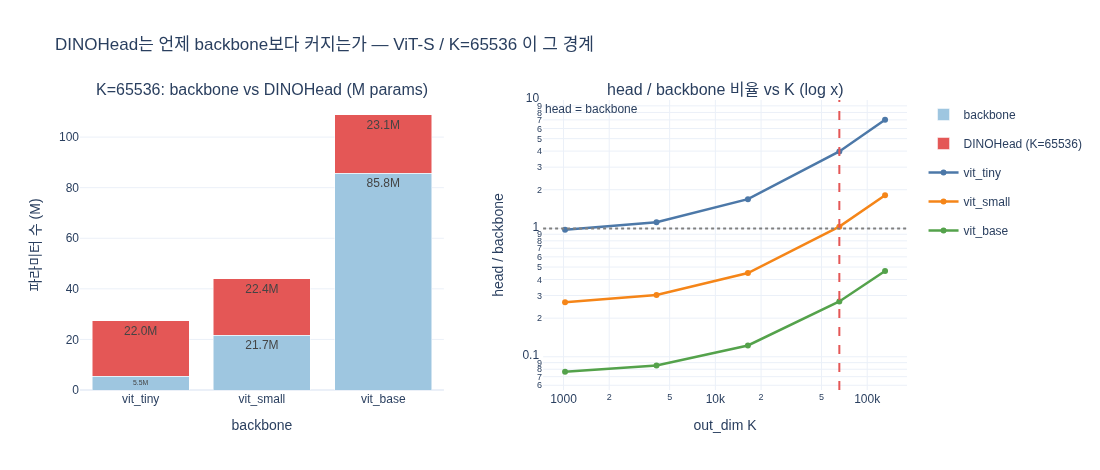

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

COLORS = {"vit_tiny": "#4C78A8", "vit_small": "#F58518", "vit_base": "#54A24B"}
archs = list(BB_DIMS)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("K=65536: backbone vs DINOHead (M params)",
                    "head / backbone 비율 vs K (log x)"),
    horizontal_spacing=0.12,
)

# (좌) 누적 막대
fig.add_trace(go.Bar(
    x=archs, y=[BB_PARAMS[a] / 1e6 for a in archs], name="backbone",
    marker_color="#9EC6E0",
    text=[f"{BB_PARAMS[a]/1e6:.1f}M" for a in archs], textposition="inside",
), row=1, col=1)
fig.add_trace(go.Bar(
    x=archs, y=[head_params_formula(BB_DIMS[a], 65536) / 1e6 for a in archs], name="DINOHead (K=65536)",
    marker_color="#E45756",
    text=[f"{head_params_formula(BB_DIMS[a],65536)/1e6:.1f}M" for a in archs], textposition="inside",
), row=1, col=1)

# (우) 비율 곡선
for a in archs:
    fig.add_trace(go.Scatter(
        x=KS, y=[head_params_formula(BB_DIMS[a], k) / BB_PARAMS[a] for k in KS],
        mode="lines+markers", name=a, line=dict(color=COLORS[a], width=2.5),
        legendgroup=a,
    ), row=1, col=2)
fig.add_hline(y=1.0, line_dash="dot", line_color="gray", row=1, col=2,
              annotation_text="head = backbone", annotation_position="bottom left")
fig.add_vline(x=65536, line_dash="dash", line_color="#E45756", row=1, col=2,
              annotation_text="기본 K=65536", annotation_position="top left")

fig.update_xaxes(title_text="backbone", row=1, col=1)
fig.update_yaxes(title_text="파라미터 수 (M)", row=1, col=1)
fig.update_xaxes(title_text="out_dim K", type="log", row=1, col=2)
fig.update_yaxes(title_text="head / backbone", type="log", row=1, col=2)
fig.update_layout(
    barmode="stack", height=470, width=1100,
    title_text="DINOHead는 언제 backbone보다 커지는가 — ViT-S / K=65536 이 그 경계",
    template="plotly_white",
)

png = os.path.join(HERE, "expy.png")
fig.write_image(png, scale=2)
print("saved:", png)
_show(fig)

## 3. 학습 메모리 함의

DINO는 student와 teacher를 **둘 다** 들고 있지만 비용이 다르다.

| 대상 | 저장하는 것 | fp32 바이트/파라미터 |
|---|---|---|
| student | param + grad + AdamW `exp_avg` + `exp_avg_sq` | $4 + 4 + 4 + 4 = 16$ |
| teacher | param만 (`requires_grad=False`, EMA로 갱신) | $4$ |

$$
\text{MB} \;=\; \frac{16\,N_{\text{student}} + 4\,N_{\text{teacher}}}{1024^2},
\qquad N_{\text{student}} = N_{\text{teacher}} = N_{bb} + N_{head}(K)
$$

활성값(activation)은 여기 포함되지 않는다 — multi-crop 10장 forward가 따로 먹는다.

In [7]:
BYTES_STUDENT = 16   # param 4 + grad 4 + AdamW 상태 2개 x 4
BYTES_TEACHER = 4    # param만


def mem_mb(n):
    return n * (BYTES_STUDENT + BYTES_TEACHER) / 1024 ** 2


print(f"{'arch':<10} {'K':>7} | {'N(M)':>7} | {'student(MB)':>11} | {'teacher(MB)':>11} | {'합계(MB)':>9}")
print("-" * 66)
for a in archs:
    for k in (4096, 65536):
        n = BB_PARAMS[a] + head_params_formula(BB_DIMS[a], k)
        s = n * BYTES_STUDENT / 1024 ** 2
        t = n * BYTES_TEACHER / 1024 ** 2
        print(f"{a:<10} {k:>7} | {n/1e6:>7.2f} | {s:>11.1f} | {t:>11.1f} | {s+t:>9.1f}")

arch             K |    N(M) | student(MB) | teacher(MB) |    합계(MB)
------------------------------------------------------------------
vit_tiny      4096 |   11.69 |       178.4 |        44.6 |     223.0
vit_tiny     65536 |   27.48 |       419.4 |       104.8 |     524.2
vit_small     4096 |   28.23 |       430.7 |       107.7 |     538.4
vit_small    65536 |   44.02 |       671.7 |       167.9 |     839.6
vit_base      4096 |   93.15 |      1421.3 |       355.3 |    1776.6
vit_base     65536 |  108.94 |      1662.2 |       415.6 |    2077.8


In [8]:
# ── K를 4096 → 65536 으로 올릴 때 ViT-S가 추가로 내는 값
n_lo = BB_PARAMS["vit_small"] + head_params_formula(384, 4096)
n_hi = BB_PARAMS["vit_small"] + head_params_formula(384, 65536)
d_par = n_hi - n_lo
print(f"추가 파라미터  : {d_par/1e6:.2f} M   (= 257 x (65536-4096) = {257*(65536-4096)/1e6:.2f} M)")
print(f"추가 메모리    : {mem_mb(d_par):.1f} MB  (student 16B + teacher 4B per param)")
print(f"→ 이 중 순수 last_layer weight_v: {256*(65536-4096)/1e6:.2f} M")

추가 파라미터  : 15.79 M   (= 257 x (65536-4096) = 15.79 M)
추가 메모리    : 301.2 MB  (student 16B + teacher 4B per param)
→ 이 중 순수 last_layer weight_v: 15.73 M


## 정리

- ViT-S/16 backbone = **21.67M**, `DINOHead(384, 65536)` = **22.35M** → head가 더 크다.
- 그 원인은 마지막 층 하나: $256 \times 65536 = 16.78$M (+ `weight_norm` 의 `weight_g` 65,536개).
- head는 $K$ 에 대해 $257K$ 로 선형 증가하고 MLP 5.51M 은 $K$ 와 무관하다.
  ViT-S의 손익분기는 $K \approx 62{,}865$ — 기본값 65536은 그 바로 위다.
- 학습 중에는 student(16 B/param) + teacher(4 B/param) 으로 약 **840 MB**,
  $K$ 를 4096에서 65536으로 올린 대가만 **약 300 MB** 다.
- 다만 **head는 학습 후 버린다** — 배포되는 ViT-S 체크포인트가 21M인 이유.